### Speech to text and Text to speech

## Assignment 7: STT + TTS Comparison

- Speech-to-Text (STT): Whisper `tiny` vs Whisper `base`
- Text-to-Speech (TTS): `edge-tts` vs `gTTS`

Input data is fixed to 5 samples from Hugging Face Marwari dataset: `1rsh/tts-rajasthani-ulca`.
The same 5 reference texts are used for TTS comparison.

In [1]:
%pip install -q openai-whisper datasets librosa soundfile edge-tts gTTS jiwer matplotlib pandas ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import os
import re
import subprocess
import sys
import time
import tempfile
import unicodedata
from difflib import SequenceMatcher

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import whisper

from datasets import Audio, load_dataset
from gtts import gTTS
from IPython.display import Audio as IPyAudio, display
from jiwer import cer, wer

In [3]:
DATASET_ID = "1rsh/tts-rajasthani-ulca"
SPLIT_CANDIDATES = ["test", "validation", "train"]
N_SAMPLES = 5

STT_MODELS = ["tiny", "base"]
TTS_MODELS = ["edge-tts", "gTTS"]
GTTS_LANG = "hi"
EDGE_TTS_VOICE = "hi-IN-SwaraNeural"
TARGET_SR = 16000

print(f"Dataset: {DATASET_ID}")
print(f"Using fixed sample count: {N_SAMPLES}")
print(f"STT models: {STT_MODELS}")
print(f"TTS models: {TTS_MODELS}")

Dataset: 1rsh/tts-rajasthani-ulca
Using fixed sample count: 5
STT models: ['tiny', 'base']
TTS models: ['edge-tts', 'gTTS']


In [4]:
def pick_split(dataset_id, split_candidates):
    for split in split_candidates:
        try:
            ds = load_dataset(dataset_id, split=split)
            print(f"Loaded split: {split} | rows: {len(ds)}")
            return ds, split
        except Exception:
            continue
    raise ValueError(f"Could not load any split from {split_candidates} for dataset {dataset_id}")


def find_audio_text_columns(ds):
    audio_col = None
    for col, feat in ds.features.items():
        if feat.__class__.__name__ == "Audio":
            audio_col = col
            break

    if audio_col is None:
        for c in ["audio", "speech", "wav", "audio_filepath", "path"]:
            if c in ds.column_names:
                audio_col = c
                break

    text_col = None
    for c in ["text", "sentence", "transcription", "transcript", "normalized_text", "label"]:
        if c in ds.column_names:
            text_col = c
            break

    if audio_col is None or text_col is None:
        raise ValueError(f"Could not detect columns. Found: {ds.column_names}")

    return audio_col, text_col


def normalize_text(s):
    if s is None:
        return ""
    s = str(s)
    s = unicodedata.normalize("NFKC", s)
    s = s.strip().lower()
    s = re.sub(r"[^\u0900-\u097Fa-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def load_audio_example(ex, audio_column, target_sr=16000):
    audio_obj = ex[audio_column]
    if isinstance(audio_obj, dict):
        if "array" in audio_obj and audio_obj["array"] is not None:
            sr = audio_obj.get("sampling_rate", target_sr)
            return np.asarray(audio_obj["array"], dtype=np.float32), sr
        if "bytes" in audio_obj and audio_obj["bytes"] is not None:
            arr, sr = librosa.load(io.BytesIO(audio_obj["bytes"]), sr=target_sr)
            return arr.astype(np.float32), sr
        if "path" in audio_obj and audio_obj["path"]:
            arr, sr = librosa.load(audio_obj["path"], sr=target_sr)
            return arr.astype(np.float32), sr
    raise ValueError(f"Unsupported audio format in column '{audio_column}'")

In [5]:
# -----------------------------
# Load exactly 5 Marwari samples (audio + same 5 text references)
# -----------------------------
raw_ds, loaded_split = pick_split(DATASET_ID, SPLIT_CANDIDATES)
audio_col, text_col = find_audio_text_columns(raw_ds)
raw_ds = raw_ds.cast_column(audio_col, Audio(sampling_rate=TARGET_SR, decode=False))

n = min(N_SAMPLES, len(raw_ds))
eval_ds = raw_ds.select(list(range(n)))

reference_texts = [normalize_text(x) for x in eval_ds[text_col]]
audio_pairs = [load_audio_example(ex, audio_col, TARGET_SR) for ex in eval_ds]

print(f"Loaded split: {loaded_split}")
print(f"Using {len(audio_pairs)} audio samples and {len(reference_texts)} matching text samples")
print("Example reference:", reference_texts[0] if reference_texts else "NA")

Loaded split: test | rows: 1848
Loaded split: test
Using 5 audio samples and 5 matching text samples
Example reference: ईं सागै ई भारत कोविड ऊं बचाव रा एके सागै दो टीका नै मंजूरी देवण वाळो दुनिया रो पेलो देश बण ग्यो है


In [6]:
# -----------------------------
# STT Comparison: Whisper tiny vs base
# -----------------------------
stt_rows = []
stt_transcripts = {}

for model_name in STT_MODELS:
    print(f"Running STT with Whisper-{model_name}...")
    model = whisper.load_model(model_name)

    preds = []
    sample_times = []
    for audio_arr, sr in audio_pairs:
        start = time.perf_counter()
        result = model.transcribe(audio_arr, language="hi", task="transcribe")
        elapsed = time.perf_counter() - start
        hyp = normalize_text(result.get("text", ""))
        preds.append(hyp)
        sample_times.append(elapsed)

    stt_transcripts[model_name] = preds
    row = {
        "Model": f"Whisper-{model_name}",
        "Avg Transcription Time (s)": round(float(np.mean(sample_times)), 3),
        "WER": round(wer(reference_texts, preds), 3),
        "CER": round(cer(reference_texts, preds), 3),
    }
    stt_rows.append(row)

stt_df = pd.DataFrame(stt_rows).sort_values(["WER", "CER"]).reset_index(drop=True)
display(stt_df)

# One clear audio-to-text example (sample 1)
print("Audio-to-Text example (sample 1):")
display(IPyAudio(data=audio_pairs[0][0], rate=audio_pairs[0][1]))
print("Reference:", reference_texts[0])
for m in STT_MODELS:
    print(f"Whisper-{m}:", stt_transcripts[m][0])

if len(STT_MODELS) == 2:
    sim = SequenceMatcher(None, stt_transcripts[STT_MODELS[0]][0], stt_transcripts[STT_MODELS[1]][0]).ratio()
    print(f"Transcript similarity on sample 1: {sim:.3f}")

Running STT with Whisper-tiny...


c:\Users\user\OneDrive\Desktop\CODE\CCNLP\.venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Running STT with Whisper-base...


,Model,Avg Transcription Time (s),WER,CER
0,Whisper-tiny,9.721,1.0,0.962
1,Whisper-base,10.807,1.0,1.000


Audio-to-Text example (sample 1):


Reference: ईं सागै ई भारत कोविड ऊं बचाव रा एके सागै दो टीका नै मंजूरी देवण वाळो दुनिया रो पेलो देश बण ग्यो है
Whisper-tiny: sales enterprises of mally buruk publici somarnini betayo ki o u karwati thor un 70 jay ja neck bham flappa
Whisper-base: 
Transcript similarity on sample 1: 0.000


In [ ]:
# -----------------------------
# TTS Comparison: edge-tts vs gTTS on same 5 reference texts
# -----------------------------
tts_rows = []
tts_example_file = None
tts_example_model = None

with tempfile.TemporaryDirectory() as tmpdir:
    # edge-tts
    try:
        synth_times = []
        durations = []
        for i, txt in enumerate(reference_texts):
            out_path = os.path.join(tmpdir, f"edge_tts_{i}.mp3")
            start = time.perf_counter()
            subprocess.run(
                [
                    sys.executable,
                    "-m",
                    "edge_tts",
                    "--voice",
                    EDGE_TTS_VOICE,
                    "--text",
                    txt,
                    "--write-media",
                    out_path,
                ],
                check=True,
                capture_output=True,
                text=True,
            )
            synth_times.append(time.perf_counter() - start)
            y, srr = librosa.load(out_path, sr=None)
            durations.append(librosa.get_duration(y=y, sr=srr))
            if i == 0:
                tts_example_file = out_path
                tts_example_model = "edge-tts"

        tts_rows.append({
            "Model": "edge-tts",
            "Avg Synthesis Time (s)": round(float(np.mean(synth_times)), 3),
            "Avg Audio Duration (s)": round(float(np.mean(durations)), 3),
            "Status": "Success",
        })
    except Exception as e:
        tts_rows.append({
            "Model": "edge-tts",
            "Avg Synthesis Time (s)": None,
            "Avg Audio Duration (s)": None,
            "Status": f"Failed: {e}",
        })

    # gTTS
    try:
        synth_times = []
        durations = []
        for i, txt in enumerate(reference_texts):
            out_path = os.path.join(tmpdir, f"gtts_{i}.mp3")
            start = time.perf_counter()
            gTTS(text=txt, lang=GTTS_LANG).save(out_path)
            synth_times.append(time.perf_counter() - start)
            y, srr = librosa.load(out_path, sr=None)
            durations.append(librosa.get_duration(y=y, sr=srr))
            if i == 0 and tts_example_file is None:
                tts_example_file = out_path
                tts_example_model = "gTTS"

        tts_rows.append({
            "Model": "gTTS",
            "Avg Synthesis Time (s)": round(float(np.mean(synth_times)), 3),
            "Avg Audio Duration (s)": round(float(np.mean(durations)), 3),
            "Status": "Success",
        })
    except Exception as e:
        tts_rows.append({
            "Model": "gTTS",
            "Avg Synthesis Time (s)": None,
            "Avg Audio Duration (s)": None,
            "Status": f"Failed: {e}",
        })

    tts_df = pd.DataFrame(tts_rows)
    display(tts_df)

    if tts_example_file is not None:
        print(f"TTS example audio (sample 1) from {tts_example_model}:")
        display(IPyAudio(filename=tts_example_file))

,Model,Avg Synthesis Time (s),Avg Audio Duration (s),Status
0,edge-tts,7.367,9.269,Success
1,gTTS,0.825,9.629,Success


TTS example audio (sample 1) from edge-tts:


In [8]:
# -----------------------------
# Final comparison summary
# -----------------------------
best_stt = stt_df.sort_values("WER", ascending=True).iloc[0]
summary_df = pd.DataFrame([
    {
        "Task": "Speech-to-Text",
        "Compared Models": ", ".join([f"Whisper-{m}" for m in STT_MODELS]),
        "Best Model": best_stt["Model"],
        "Best Metric": f"WER={best_stt['WER']}, CER={best_stt['CER']}",
    },
    {
        "Task": "Text-to-Speech",
        "Compared Models": ", ".join(TTS_MODELS),
        "Best Model": tts_df.dropna(subset=["Avg Synthesis Time (s)"]).sort_values("Avg Synthesis Time (s)").iloc[0]["Model"] if tts_df["Avg Synthesis Time (s)"].notna().any() else "No successful model",
        "Best Metric": "Lowest Avg Synthesis Time",
    },
])
display(summary_df)

,Task,Compared Models,Best Model,Best Metric
0,Speech-to-Text,"Whisper-tiny, Whisper-base",Whisper-tiny,"WER=1.0, CER=0.962"
1,Text-to-Speech,"edge-tts, gTTS",gTTS,Lowest Avg Synthesis Time


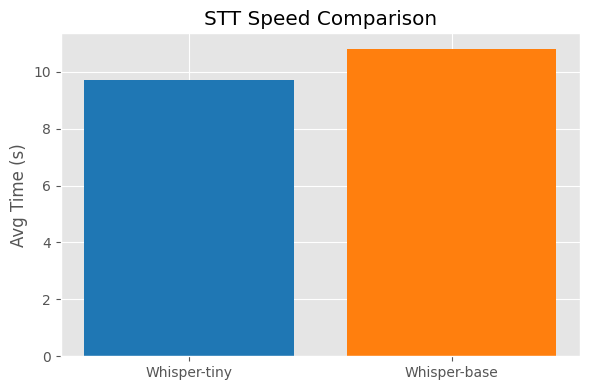

In [12]:
# STT timing
plt.style.use("ggplot")
plt.figure(figsize=(6, 4))
plt.bar(stt_df["Model"], stt_df["Avg Transcription Time (s)"], color=["#1f77b4", "#ff7f0e"][:len(stt_df)])
plt.title("STT Speed Comparison")
plt.ylabel("Avg Time (s)")
plt.tight_layout()
plt.show()

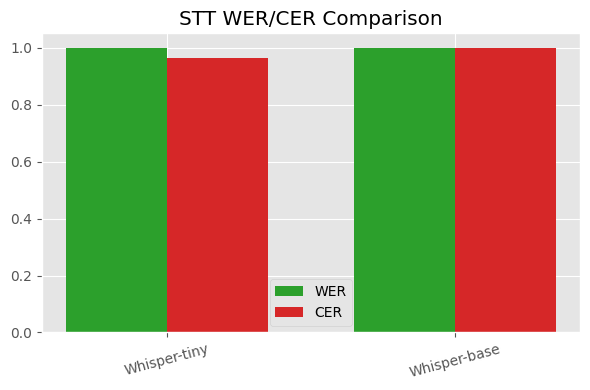

In [13]:
# STT error metrics
plt.style.use("ggplot")
x = np.arange(len(stt_df))
w = 0.35
plt.figure(figsize=(6, 4))
plt.bar(x - w/2, stt_df["WER"], width=w, label="WER", color="#2ca02c")
plt.bar(x + w/2, stt_df["CER"], width=w, label="CER", color="#d62728")
plt.xticks(x, stt_df["Model"], rotation=15)
plt.title("STT WER/CER Comparison")
plt.legend()
plt.tight_layout()
plt.show()

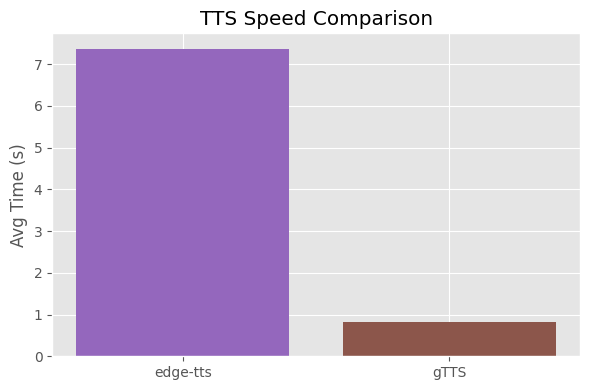

In [14]:
# TTS timing
plt.style.use("ggplot")
ok_tts = tts_df.dropna(subset=["Avg Synthesis Time (s)"])
plt.figure(figsize=(6, 4))
if not ok_tts.empty:
    plt.bar(ok_tts["Model"], ok_tts["Avg Synthesis Time (s)"], color=["#9467bd", "#8c564b"][:len(ok_tts)])
    plt.ylabel("Avg Time (s)")
    plt.title("TTS Speed Comparison")
else:
    plt.text(0.5, 0.5, "No successful TTS run", ha="center", va="center")
    plt.title("TTS Speed Comparison")
    plt.axis("off")
plt.tight_layout()
plt.show()